In [1]:
from pathlib import Path
import sys
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import contextily as cx
from adjustText import adjust_text
import numpy as np
import pickle
from shapely.geometry import Point
from shapely.geometry import box

In [2]:
# ------- Paths -------
data_caravan=Path("/inputs/data_updated_2/time_series")
data_camels=Path("/inputs/basin_dataset_public_v1p2/basin_mean_forcing/daymet") #camels
data_caravan_2=Path("../extending_caravan/data/time_series")


In [3]:
DATA_DIR = Path("../extending_caravan/data")
ATTRIBUTES_FILE = Path('../extending_caravan/data/attributes/attributes_caravan.csv')
location_file = Path('../extending_caravan/data/attributes/attributes_other.csv')
basins_path = Path("../extending_caravan/basins_excluded.txt")

# Figure 1: CAMELS VS ERA5 vs CHIRPS vs MSWEP in th US

In [4]:
with open(basins_path, "r") as f:
    basins = f.read().splitlines()

In [5]:
attributes_df = pd.read_csv(ATTRIBUTES_FILE)
attributes_df = attributes_df[attributes_df["gauge_id"].isin(basins)]
attributes_df.head()

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
23,camels_01181000,3.812841,0.517986,0.223071,1.100840,0.053799,3.200636,0.620192,-0.695785,0.505404,3.765760,14.358241,1.950612,0.370373,0.891910
31,camels_01411300,6.547902,0.850316,0.000000,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
40,camels_01440400,4.253795,0.574181,0.215014,1.122053,0.055373,3.328762,0.631348,-0.741846,0.456636,3.511197,14.935913,2.016063,0.243502,0.926743
46,camels_01487000,2.148131,0.816437,0.000000,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.000000,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539


In [6]:
basins_without_snow = attributes_df[attributes_df["frac_snow"] == 0]
basins_without_snow

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
31,camels_01411300,6.547902,0.850316,0.0,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
46,camels_01487000,2.148131,0.816437,0.0,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.0,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539
82,camels_01644000,6.478690,0.786511,0.0,1.146575,0.057290,3.723380,0.672553,-0.831573,0.262752,2.882359,18.673912,2.267007,0.166854,1.113510
84,camels_01664000,6.257002,0.787302,0.0,1.160563,0.056400,3.757483,0.670226,-0.827592,0.263094,2.907870,18.194550,2.289372,0.154660,1.079264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,camels_08200000,5.892580,1.480150,0.0,1.338816,0.055715,5.378307,0.695756,-0.818055,-0.206494,2.355404,13.879405,3.486350,0.179898,0.972996
478,camels_08202700,5.354751,1.543873,0.0,1.343802,0.055647,5.494394,0.704381,-0.799316,-0.236503,2.294640,12.287230,3.542635,0.203036,0.963851
510,camels_09484600,7.586109,3.427976,0.0,1.458609,0.060301,8.970454,0.810472,-0.844949,-0.632137,1.021377,7.748279,3.501256,0.309929,0.862510
547,camels_11124500,18.177790,2.793685,0.0,1.534381,0.053457,14.039216,0.882135,-0.916015,-0.427672,1.197652,21.770658,3.345862,0.244175,1.529678


In [7]:
basins_without_snow_list = basins_without_snow["gauge_id"]
basins_without_snow_list.to_csv("basins_without_snow.txt", index=False, header=False)

In [8]:
location = pd.read_csv(location_file)
location_without_snow = location[location["gauge_id"].isin(basins_without_snow_list)]
location_without_snow

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
31,camels_01411300,TUCKAHOE RIVER AT HEAD OF RIVER NJ,United States of America,39.30694,-74.82056,79.230476
46,camels_01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",United States of America,38.72833,-75.56186,187.283875
47,camels_01491000,"CHOPTANK RIVER NEAR GREENSBORO, MD",United States of America,38.99719,-75.78581,291.553355
82,camels_01644000,"GOOSE CREEK NEAR LEESBURG, VA",United States of America,39.01955,-77.57749,858.811596
84,camels_01664000,"RAPPAHANNOCK RIVER AT REMINGTON, VA",United States of America,38.53068,-77.81360,1603.511552
...,...,...,...,...,...,...
477,camels_08200000,"Hondo Ck nr Tarpley, TX",United States of America,29.56967,-99.24671,249.577750
478,camels_08202700,"Seco Ck at Rowe Ranch nr D'Hanis, TX",United States of America,29.37079,-99.28782,431.340606
510,camels_09484600,"PANTANO WASH NEAR VAIL, AZ.",United States of America,32.03591,-110.67758,1241.049373
547,camels_11124500,SANTA CRUZ C NR SANTA YNEZ CA,United States of America,34.59666,-119.90875,192.472798


In [9]:
# def plot_nse_map(RUN_PREFIX,NSE_THRESHOLD=None):
#     """
#     Plot NSE values from the latest model_epoch directory with basemap.
    
#     Parameters:
#     -----------
#     run_dir_name : str or Path
#         Name of the run directory inside './runs'.
#     period : str or Path
#         Subdirectory under the run directory (e.g., 'validation').
#     """
    
#     file_path = f"../extending_caravan/runs/{RUN_PREFIX}/validation/model_epoch030/validation_results.p"


#     with open(file_path, "rb") as f:
#         data = pickle.load(f)

#     print(f"Loaded {len(data)} catchments")

#     nse_values = {"catchment": [], "nse_values": []}

#     for catchment in data.keys():

#         NSE = data[catchment]["1D"]["NSE"]
#         nse_values["catchment"].append(catchment)
#         nse_values["nse_values"].append(NSE)

#     # Load attributes
#     attributes = pd.read_csv(location_file) #.set_index("gauge_id")

#     # Create GeoDataFrame
#     gdf = gpd.GeoDataFrame(
#         attributes,
#         geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
#         crs="EPSG:4326"
#     )

#     gdf["NSE"] = gdf["gauge_id"].map(dict(zip(nse_values["catchment"], nse_values["nse_values"])))
#     gdf = gdf.dropna(subset=["NSE"])

#     # Convert to Web Mercator for basemap
#     gdf_web = gdf.to_crs(epsg=3857)

#     # Plot
#     fig, ax = plt.subplots(figsize=(12, 6))
#     plot = gdf_web.plot(
#         column="NSE",
#         cmap="viridis",
#         legend=True,
#         markersize=60,
#         ax=ax,
#         vmin=0,
#         vmax=1
#     )

#     # Add colorbar label
#     cbar = plot.get_figure().get_axes()[1]
#     cbar.set_ylabel("ensemble_nse", rotation=270, labelpad=15)

#     ax.set_title("NSE by Gauge Location")

#     # Define CONUS bounds in lat/lon
#     conus_bounds = box(-125, 24, -66.5, 50)  # (minx, miny, maxx, maxy)

#     # Convert to GeoDataFrame and project to Web Mercator
#     conus_gdf = gpd.GeoDataFrame(geometry=[conus_bounds], crs="EPSG:4326")
#     conus_gdf_web = conus_gdf.to_crs(epsg=3857)

#     # Extract projected bounds
#     xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

#     # Set fixed extent
#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     # Add basemap
#     cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

#     plt.show()

In [10]:
# # RUN_PREFIX = "caravan_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_185008"
# RUN_PREFIX = "precip_chirps_precipitation_0503_093821"
# plot_nse_map(RUN_PREFIX)

In [11]:
attributes = pd.read_csv(
    "/inputs/data_updated_2/attributes/attributes_other.csv"
).set_index("gauge_id")

In [12]:
with open("basins_without_snow.txt", "r") as f:
    basins = [b.strip() for b in f if b.strip()]

results = []

for basin_id in basins:
    camels_id = basin_id.replace("camels_", "")

    # --- Open CARAVAN ---
    caravan_file = data_caravan_2 / f"{basin_id}.nc"
    if not caravan_file.exists():
        print(f"No CARAVAN file for {basin_id}")
        continue

    caravan = xr.open_dataset(caravan_file)

    # --- Find CAMELS txt ---
    csv_files = list(data_camels.glob(f"**/{camels_id}*.txt"))
    if not csv_files:
        print(f"No CAMELS file for {basin_id}")
        continue

    csv_file = csv_files[0]

    # --- Load CAMELS precip ---
    df = pd.read_csv(csv_file, skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df = df.set_index("date")

    # --- Build xarray objects ---
    precip_caravan = caravan["total_precipitation_sum"]
    precip_era5 = caravan["era5land_total_precipitation"]
    precip_chirps = caravan["chirps_precipitation"]
    precip_mswep = caravan["mswep_precipitation"]

    precip_camels = xr.DataArray(
        df["prcp(mm/day)"],
        coords={"date": df.index},
        dims="date",
        name="prcp"
    )

    # --- Align ---
    pr_car, pr_cam, pr_era5, pr_chirps, pr_mswep = xr.align(
        precip_caravan,
        precip_camels,
        precip_era5,
        precip_chirps,
        precip_mswep,
        join="inner"
    )

    # --- Time window ---
    pr_car = pr_car.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_cam = pr_cam.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_era5 = pr_era5.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_chirps = pr_chirps.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_mswep = pr_mswep.sel(date=slice("1989-10-01", "2008-09-30"))

    # --- Remove NaNs ---
    mask = ~np.isnan(pr_car)
    pr_car = pr_car[mask]
    pr_cam = pr_cam[mask]
    pr_era5 = pr_era5[mask]
    pr_chirps = pr_chirps[mask]
    pr_mswep = pr_mswep[mask]

    # --- Dry-day ratios ---
    dry_caravan_ratio = float((pr_car == 0).sum() / pr_car.size)
    dry_camels_ratio  = float((pr_cam == 0).sum() / pr_cam.size)
    dry_era5_ratio   = float((pr_era5 == 0).sum() / pr_era5.size)
    dry_chirps_ratio = float((pr_chirps == 0).sum() / pr_chirps.size)
    dry_mswep_ratio  = float((pr_mswep == 0).sum() / pr_mswep.size)

    if basin_id in attributes.index:
        gauge_lat = attributes.loc[basin_id, "gauge_lat"]
        gauge_lon = attributes.loc[basin_id, "gauge_lon"]
    else:
        gauge_lat = np.nan
        gauge_lon = np.nan

    results.append({
        "basin": basin_id,
        "dry_ratio_caravan": float((pr_car == 0).sum() / pr_car.size),
        "dry_ratio_camels": float((pr_cam == 0).sum() / pr_cam.size),
        "dry_ratio_era5": float((pr_era5 == 0).sum() / pr_era5.size),
        "dry_ratio_chirps": float((pr_chirps == 0).sum() / pr_chirps.size),
        "dry_ratio_mswep": float((pr_mswep == 0).sum() / pr_mswep.size),
        "gauge_lat": gauge_lat,
        "gauge_lon": gauge_lon,
    })

    caravan.close()

In [13]:
df_results = pd.DataFrame(results)

gdf = gpd.GeoDataFrame(
    df_results,
    geometry=gpd.points_from_xy(
        df_results["gauge_lon"],
        df_results["gauge_lat"]
    ),
    crs="EPSG:4326"
)

# Convert to Web Mercator for basemap
gdf_web = gdf.to_crs(epsg=3857)

In [14]:
# # Convert to Web Mercator for basemap
# gdf_web = gdf.to_crs(epsg=3857)

# # Plot dry-day ratio from CARAVAN
# fig, ax = plt.subplots(figsize=(12, 6))
# plot = gdf_web.plot(
#     column="dry_ratio_mswep",  # or "dry_ratio_camels"
#     cmap="viridis",
#     legend=True,
#     markersize=60,
#     ax=ax,
#     vmin=0,  # optional: set min/max if you want consistent scale
#     vmax=1
# )

# # Adjust colorbar label
# cbar = plot.get_figure().get_axes()[1]
# cbar.set_ylabel("Dry-day ratio (CARAVAN)", rotation=270, labelpad=15)


# # Define CONUS bounds in lat/lon
# conus_bounds = box(-125, 24, -66.5, 50)  # (minx, miny, maxx, maxy)

# # Convert to GeoDataFrame and project to Web Mercator
# conus_gdf = gpd.GeoDataFrame(geometry=[conus_bounds], crs="EPSG:4326")
# conus_gdf_web = conus_gdf.to_crs(epsg=3857)

# # Extract projected bounds
# xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

# # Set fixed extent
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# # Add basemap
# cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

# # Add title
# ax.set_title("Dry-day Ratio by Gauge Location (CARAVAN)")

# plt.show()

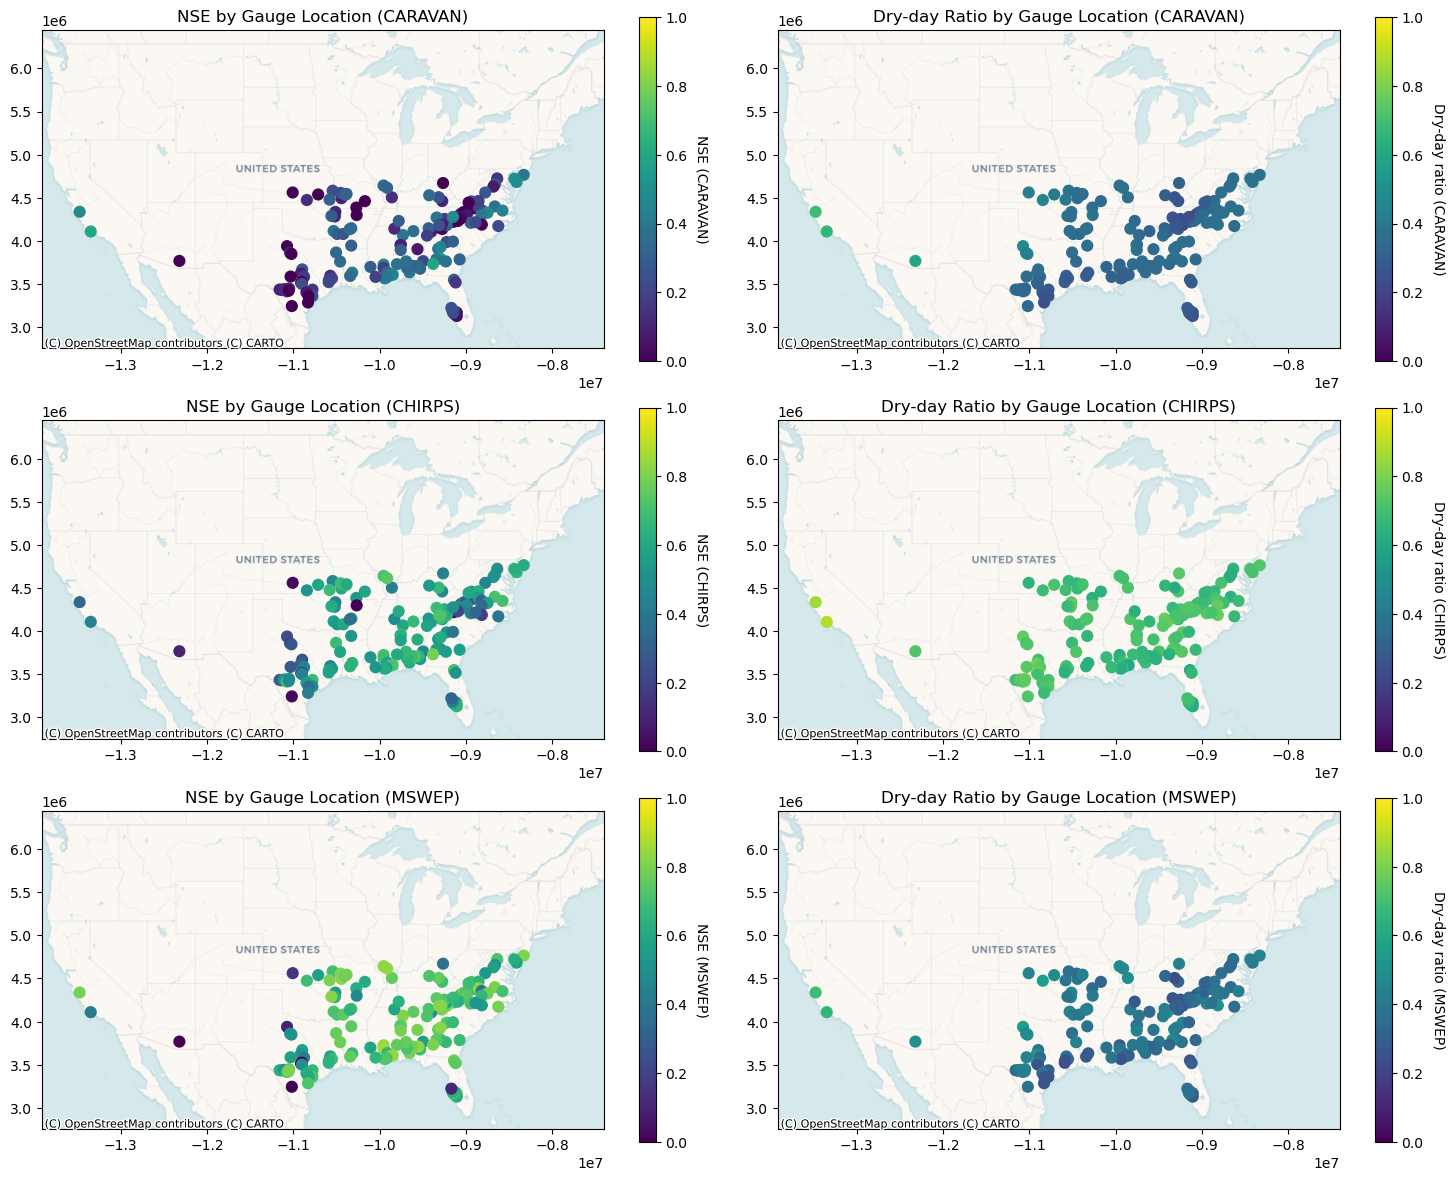

In [15]:
# --- Config ---
CONUS_BOUNDS = box(-125, 24, -66.5, 50)
conus_gdf_web = gpd.GeoDataFrame(geometry=[CONUS_BOUNDS], crs="EPSG:4326").to_crs(epsg=3857)
xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

RUN_PREFIXES = [
    "caravan_154_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_211409",
    "precip_chirps_precipitation_0503_093821",
    "precip_mswep_precipitation_0503_110038",
]

plot_configs = [
    ("dry_ratio_caravan", "CARAVAN", RUN_PREFIXES[0]),
    ("dry_ratio_chirps",  "CHIRPS",  RUN_PREFIXES[1]),
    ("dry_ratio_mswep",   "MSWEP",   RUN_PREFIXES[2]),
]

# --- Load NSE data helper ---
def load_nse_gdf(run_prefix):
    file_path = f"../extending_caravan/runs/{run_prefix}/validation/model_epoch030/validation_results.p"
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    nse_map = {catchment: data[catchment]["1D"]["NSE"] for catchment in data}

    attributes = pd.read_csv(location_file)
    gdf = gpd.GeoDataFrame(
        attributes,
        geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
        crs="EPSG:4326"
    )
    gdf["NSE"] = gdf["gauge_id"].map(nse_map)
    gdf = gdf.dropna(subset=["NSE"])
    return gdf.to_crs(epsg=3857)

# --- Plot ---
fig, ax = plt.subplots(3, 2, figsize=(15, 12))

for row, (dry_col, label, run_prefix) in enumerate(plot_configs):

    # --- Left: NSE map ---
    nse_gdf = load_nse_gdf(run_prefix)
    nse_gdf.plot(
        column="NSE",
        cmap="viridis",
        legend=True,
        markersize=60,
        ax=ax[row, 0],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel(f"NSE ({label})", rotation=270, labelpad=15)
    ax[row, 0].set_xlim(xmin, xmax)
    ax[row, 0].set_ylim(ymin, ymax)
    cx.add_basemap(ax[row, 0], source=cx.providers.CartoDB.Voyager)
    ax[row, 0].set_title(f"NSE by Gauge Location ({label})")

    # --- Right: Dry-day ratio map ---
    gdf_web.plot(
        column=dry_col,
        cmap="viridis",
        legend=True,
        markersize=60,
        ax=ax[row, 1],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel(f"Dry-day ratio ({label})", rotation=270, labelpad=15)
    ax[row, 1].set_xlim(xmin, xmax)
    ax[row, 1].set_ylim(ymin, ymax)
    cx.add_basemap(ax[row, 1], source=cx.providers.CartoDB.Voyager)
    ax[row, 1].set_title(f"Dry-day Ratio by Gauge Location ({label})")

plt.tight_layout()
plt.show()

Runs that I want to include:

- Whole CAMELS and dry ratio 

# Figure 2: Precip comparison

In [16]:
basin = 'camels_01440400'
number = basin.split("_")[1]

In [17]:
caravan = xr.open_dataset(data_caravan / f"{basin}.nc")
csv_files = list(data_camels.glob(f"**/{number}*.txt"))

csv_files = list(data_camels.glob(f"**/{number}*.txt"))
# if not csv_files:
#     print(f"No CSV found for {basin_id}")
#     continue
csv_file = csv_files[0]

# Load CSV
df = pd.read_csv(csv_file, skiprows=3, sep=r"\s+")
df["date"] = pd.to_datetime(
    df[["Year", "Mnth", "Day"]].rename(columns={
        "Year": "year",
        "Mnth": "month",
        "Day": "day"
    })
)
df = df.set_index("date")

In [18]:
# Align by date first (so we sum over the same days)
precip_caravan = caravan['total_precipitation_sum']
precip_camels = xr.DataArray(
    df['prcp(mm/day)'],
    coords={'date': df.index},
    dims='date',
    name='prcp'
)

precip_caravan_aligned, precip_camels_aligned = xr.align(
    precip_caravan,
    precip_camels,
    join='inner'
)

In [19]:
start_date = pd.Timestamp("1989-10-01")
end_date   = pd.Timestamp("2008-09-30")

In [20]:
precip_caravan_sel = precip_caravan_aligned.sel(date=slice(start_date, end_date))
precip_camels_sel   = precip_camels_aligned.sel(date=slice(start_date, end_date))

In [21]:
# Compute cumulative precipitation for both series
cum_caravan = precip_caravan_sel.cumsum(dim='date').values.flatten()
cum_camels = precip_camels_sel.cumsum(dim='date').values.flatten()

# # Scatter plot: x = Caravan, y = UY gauge
# plt.figure(figsize=(6,6))
# plt.plot(cum_caravan, cum_camels)
# plt.xlabel('Cumulative Caravan Precipitation (mm)')
# plt.ylabel('Cumulative Camels Precipitation (mm)')
# plt.title('Cumulative Precipitation Comparison')
# plt.grid(True)

# # Optional: 1:1 line to see perfect agreement
# max_val = max(cum_caravan.max(), cum_camels.max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
# plt.legend()
# plt.show()

In [22]:
# --- Flatten & remove NaNs ---
pr_caravan = precip_caravan_sel[~np.isnan(precip_caravan_sel)]
pr_camels = precip_camels_sel[~np.isnan(precip_caravan_sel)]

# --- Sort descending ---
pr_caravan_sorted = np.sort(pr_caravan)[::-1]
pr_camels_sorted = np.sort(pr_camels)[::-1]

# --- Exceedance probabilities ---
n_caravan = len(pr_caravan_sorted)
n_camels = len(pr_camels_sorted)

ep_caravan = np.arange(1, n_caravan + 1) / (n_caravan + 1) * 100
ep_camels = np.arange(1, n_camels + 1) / (n_camels + 1) * 100

# --- Plot ---
pr_caravan_plot = np.where(pr_caravan_sorted==0, 1e-3, pr_caravan_sorted)
pr_camels_plot   = np.where(pr_camels_sorted==0, 1e-3, pr_camels_sorted)

# plt.figure(figsize=(7, 5))

# plt.plot(ep_caravan, pr_caravan_plot, label="CARAVAN", lw=2)
# plt.plot(ep_camels, pr_camels_plot, label="Gauge", lw=2)

# plt.xlabel("Exceedance probability (%)")
# plt.ylabel("Daily precipitation (mm)")
# plt.yscale("log")
# plt.grid(True, which="both", ls="--", alpha=0.5)
# plt.legend()
# plt.title("Precipitation Duration Curve")

# plt.tight_layout()
# plt.show()

In [23]:
caravan_zero_count = np.sum(pr_caravan == 0.0).values
camels_zero_count = np.sum(pr_camels == 0.0).values


# --- Step 1: Define function to get consecutive zeros ---
def get_consecutive_lengths(bool_array):
    diff = np.diff(bool_array.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1
    if bool_array[0]:
        starts = np.r_[0, starts]
    if bool_array[-1]:
        ends = np.r_[ends, len(bool_array)]
    lengths = ends - starts
    return lengths

# --- Step 2: Convert to boolean arrays for both datasets ---
dry_caravan = (pr_caravan == 0)
dry_camels   = (pr_camels   == 0)

# --- Step 3: Get consecutive zero lengths ---
dry_lengths_caravan = get_consecutive_lengths(dry_caravan)
dry_lengths_camels   = get_consecutive_lengths(dry_camels)

# --- Step 4: Plot histograms together ---
plt.figure(figsize=(8,5))

max_len = max(
    dry_lengths_caravan.max(),
    dry_lengths_camels.max()
)

bins = np.arange(1, max_len + 2) - 0.5

# plt.hist(dry_lengths_caravan, bins=bins, histtype="step", lw=2, label="CARAVAN")
# plt.hist(dry_lengths_camels,   bins=bins, histtype="step", lw=2, label="CAMELS")

# plt.xlabel("Dry spell length (days)")
# plt.ylabel("Frequency")
# plt.title("Histogram of Dry Period Lengths")
# plt.legend()
# plt.grid(True, ls='--', alpha=0.5)
# plt.show()

<Figure size 800x500 with 0 Axes>

In [24]:
# Extract arrays
precip_caravan = precip_caravan_sel.values
precip_camels = precip_camels_sel.values
dates = pd.to_datetime(precip_caravan_sel.date.values)

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'caravan': precip_caravan,
    'camels': precip_camels
})

# Extract year and day-of-year
df['year'] = df['date'].dt.year
df['doy'] = df['date'].dt.dayofyear

# Compute median for each day-of-year (across all years)
median_caravan = df.groupby('doy')['caravan'].median().values
median_camels = df.groupby('doy')['camels'].median().values

# Handle leap years
if len(median_caravan) == 366:
    median_caravan = median_caravan[:365]
if len(median_camels) == 366:
    median_camels = median_camels[:365]

# Stack into 2D array
all_precip = np.array([median_caravan, median_camels])

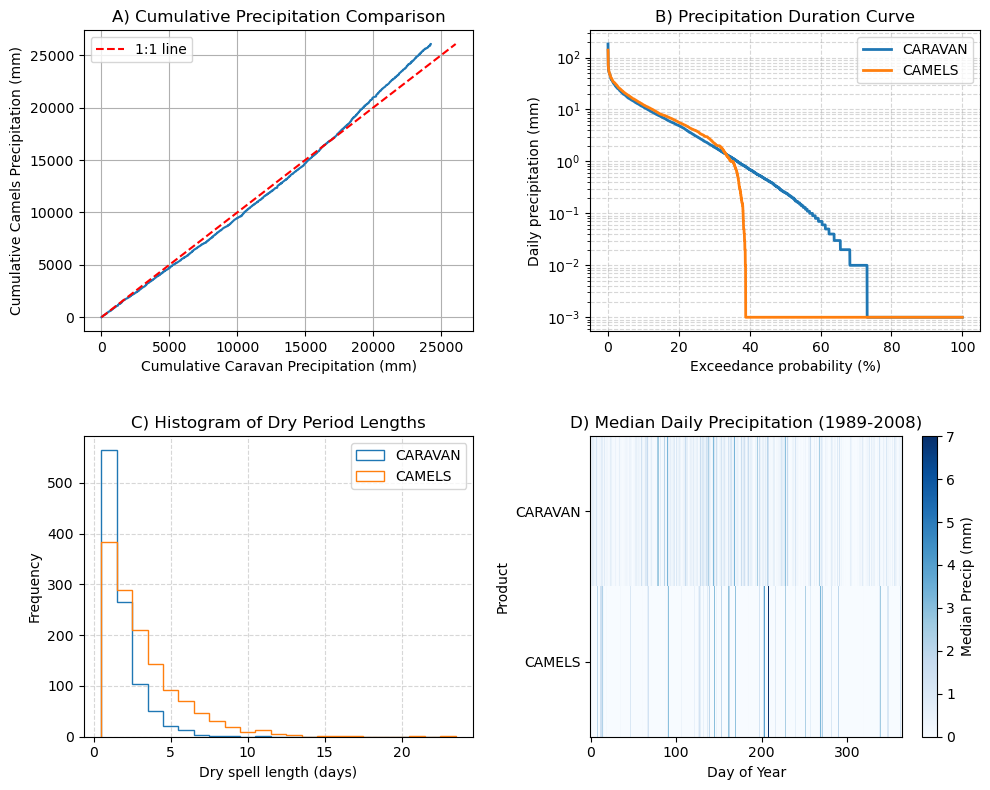

In [25]:
fix, ax = plt.subplots(2, 2, figsize=(10,8))

# ------------- Plot 1: Cumulative Precipitation Comparison -------------

# Scatter plot: x = Caravan, y = UY gauge
ax[0,0].plot(cum_caravan, cum_camels)
ax[0,0].set_xlabel('Cumulative Caravan Precipitation (mm)')
ax[0,0].set_ylabel('Cumulative Camels Precipitation (mm)')
ax[0,0].set_title('A) Cumulative Precipitation Comparison')
ax[0,0].grid(True)

# Optional: 1:1 line to see perfect agreement
max_val = max(cum_caravan.max(), cum_camels.max())
ax[0,0].plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
ax[0,0].legend()

# ------------- Plot 2: Precipitation Duration Curve -------------

ax[0,1].plot(ep_caravan, pr_caravan_plot, label="CARAVAN", lw=2)
ax[0,1].plot(ep_camels, pr_camels_plot, label="CAMELS", lw=2)

ax[0,1].set_xlabel("Exceedance probability (%)")
ax[0,1].set_ylabel("Daily precipitation (mm)")
ax[0,1].set_yscale("log")
ax[0,1].grid(True, which="both", ls="--", alpha=0.5)
ax[0,1].legend()
ax[0,1].set_title("B) Precipitation Duration Curve")

# ------------- Plot 3: Histogram of Dry Period Lengths -------------

ax[1,0].hist(dry_lengths_caravan, bins=bins, histtype="step", lw=2, label="CARAVAN")
ax[1,0].hist(dry_lengths_camels,   bins=bins, histtype="step", lw=2, label="CAMELS")

ax[1,0].set_xlabel("Dry spell length (days)")
ax[1,0].set_ylabel("Frequency")
ax[1,0].set_title("C) Histogram of Dry Period Lengths")
ax[1,0].legend()
ax[1,0].grid(True, ls='--', alpha=0.5)


# ------------- Plot 4: Median Seasonal Cycle -------------

# CREATE HEATMAP
im = ax[1,1].imshow(all_precip, aspect='auto', cmap='Blues',vmin=0,vmax=7, interpolation='nearest')

ax[1,1].set_yticks([0, 1])
ax[1,1].set_yticklabels(['CARAVAN', 'CAMELS'])
ax[1,1].set_xlabel('Day of Year')
ax[1,1].set_ylabel('Product')
ax[1,1].set_title('D) Median Daily Precipitation (1989-2008)')

cbar = plt.colorbar(im, ax=ax[1,1])
cbar.set_label('Median Precip (mm)')

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()

In [26]:
# # CREATE HEATMAP
# fig, ax = plt.subplots(figsize=(20, 4))
# im = ax.imshow(all_precip, aspect='auto', cmap='Blues', interpolation='nearest')

# ax.set_yticks([0, 1])
# ax.set_yticklabels(['CARAVAN', 'CAMELS'])
# ax.set_xlabel('Day of Year')
# ax.set_ylabel('Product')
# ax.set_title('Median Daily Precipitation (1989-2008)')

# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label('Median Precip (mm)')

# plt.tight_layout()
# # plt.savefig('median_heatmap.png', dpi=300, bbox_inches='tight')
# plt.show()